In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

In [8]:
data = pd.read_csv('gapminder.csv').dropna()

data.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [9]:
continent = pd.get_dummies(data['continent'], drop_first=True).astype(int)
data = pd.concat([data,continent], axis=1)
data.head()

,country,continent,year,lifeExp,pop,gdpPercap,Americas,Asia,Europe,Oceania
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,0,1,0,0
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,0,1,0,0
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,0,1,0,0
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,0,1,0,0
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,0,1,0,0


In [10]:
inputs = ['pop','gdpPercap','year','Americas','Asia','Europe','Oceania']
data[inputs].corr()

,pop,gdpPercap,year,Americas,Asia,Europe,Oceania
pop,1.000000,-0.025600,8.230808e-02,-2.219817e-02,2.459466e-01,-6.062454e-02,-2.334280e-02
gdpPercap,-0.025600,1.000000,2.273181e-01,-3.715837e-03,3.834877e-02,3.809787e-01,1.383432e-01
year,0.082308,0.227318,1.000000e+00,-1.574294e-15,2.402565e-15,2.118443e-15,-6.039044e-15
Americas,-0.022198,-0.003716,-1.574294e-15,1.000000e+00,-2.543436e-01,-2.392372e-01,-5.524946e-02
Asia,0.245947,0.038349,2.402565e-15,-2.543436e-01,1.000000e+00,-2.847707e-01,-6.576498e-02
Europe,-0.060625,0.380979,2.118443e-15,-2.392372e-01,-2.847707e-01,1.000000e+00,-6.185896e-02
Oceania,-0.023343,0.138343,-6.039044e-15,-5.524946e-02,-6.576498e-02,-6.185896e-02,1.000000e+00


In [11]:
train, test = train_test_split(data, test_size=0.3, random_state=2024)

model = sm.OLS(train['lifeExp'],train[inputs]).fit()

Text(0, 0.5, 'Actual')

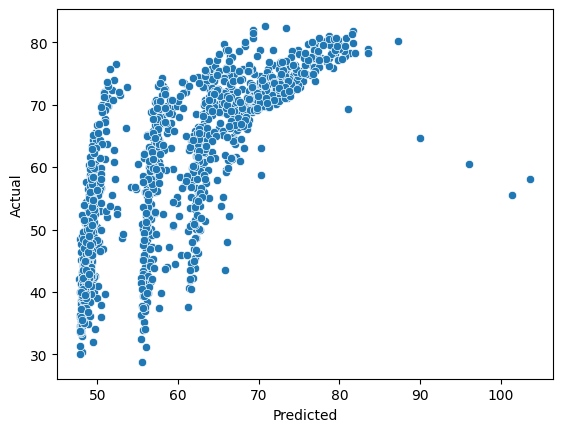

In [12]:
sns.scatterplot(y=train['lifeExp'], x=model.predict(train[inputs]))
plt.xlabel('Predicted')
plt.ylabel('Actual')

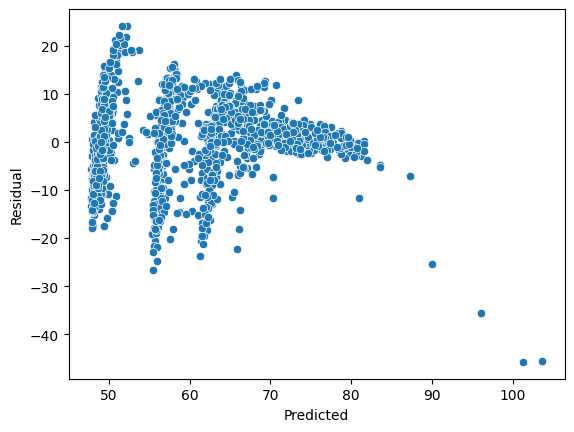

In [13]:
residuals = train['lifeExp'] - model.predict(train[inputs])
sns.scatterplot(x=model.predict(train[inputs]),y=residuals)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.show()

Text(0, 0.5, 'Residual')

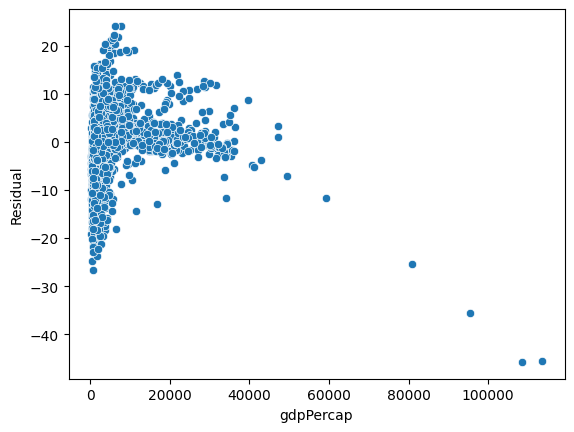

In [14]:
residuals = train['lifeExp'] - model.predict(train[inputs])
sns.scatterplot(x=train['gdpPercap'],y=residuals)
plt.ylabel('Residual')

In [ ]:
sns.scatterplot(x=data['gdpPercap'],y=data['lifeExp'])

In [ ]:
sns.scatterplot(x=np.log(data['gdpPercap']),y=data['lifeExp'])